# Analysis of Global Scientific Production (2000–2025)

In this notebook, we examine the scientific output of the 15 most productive countries according to Scimago Journal & Country Rank (https://www.scimagojr.com/countryrank.php). Using data obtained through the OpenAlex API (https://openalex.org), Scopus and Web Of Science, we collect the number of published scientific articles per year from 2000 to 2025 for each country.

The search in Scopus was "AFFILCOUNTRY(countryName) AND PUBYEAR > 1999 AND PUBYEAR < 2026". The search in Web Of Science was "CU=countryName and PY=(2000-2025)". The data can be accessed from https://github.com/cossorzano/COSS_DataAnalysis_notebooks/blob/main/Notebooks/dataPublications2025.zip

The analysis is performed in two complementary ways:
* Absolute production — the total number of articles published each year, showing the evolution of global research output and revealing how different countries have contributed to its growth.

* Normalized production — each country’s publication counts are divided by their respective 2021 value, allowing comparison of relative growth trends independently of total size.

Finally, we compute the median normalized profile across all countries to obtain a representative global trend of scientific production over the past 25 years.

## Results

The median curve shows a distinct **rise-and-fall** pattern in global scientific production between 2000 and 2024.

From 2000 to around 2020, the normalized median number of articles increases steadily, with an average annual growth rate of about 3.5 % (slope = 0.035). This long ascent reflects a broad expansion of worldwide research capacity, increased international collaboration, and the continuous growth of indexed journals and research funding.

After peaking near 2021, the trend reverses: the normalized median declines with an average annual decrease of roughly 3.5 % (slope = –0.035). This downturn points to a contraction following two decades of rapid growth. Possible causes include the COVID-19 pandemic’s disruption of research activity, changes in publication incentives, and a slowdown in funding growth in some major economies.

Overall, the curve captures a 20-year phase of expansion followed by a recent and sharper decline, indicating that the remarkable rise in global scientific production that characterized the early 21st century has begun to recede in the most recent years.

In [1]:
import os
import csv
import glob
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data from OpenAlex

In [2]:
def getWorksFromCountryAll(country):
  base = "https://api.openalex.org/works"
  params = {
      # institution lineage, type=article, and year range
      "filter": f"authorships.institutions.country_code:{country},type:article,publication_year:2000-2025",
      # be nice to their API
      "mailto": "coss@cnb.csic.es",
      # group counts by year
      "group_by": "publication_year",
      # large page size to return all groups in one shot
      "per_page": 200,
  }

  r = requests.get(base, params=params, timeout=60)
  r.raise_for_status()
  data = r.json()

  # The response has groups with {"key": "YYYY", "count": N}
  groups = data.get("group_by") or data  # some clients show a bare list; handle both
  df = pd.DataFrame(groups)
  df["year"] = df["key"].astype(int)
  df = df.sort_values("year", ascending=True)[["year", "count"]].reset_index(drop=True)

  return df

In [3]:
worksOA={}
worksOA["US"]=getWorksFromCountryAll("US")
worksOA["CN"]=getWorksFromCountryAll("CN")
worksOA["GB"]=getWorksFromCountryAll("GB")
worksOA["DE"]=getWorksFromCountryAll("DE")
worksOA["JP"]=getWorksFromCountryAll("JP")
worksOA["IN"]=getWorksFromCountryAll("IN")
worksOA["FR"]=getWorksFromCountryAll("FR")
worksOA["IT"]=getWorksFromCountryAll("IT")
worksOA["CA"]=getWorksFromCountryAll("CA")
worksOA["AU"]=getWorksFromCountryAll("AU")
worksOA["ES"]=getWorksFromCountryAll("ES")
worksOA["RU"]=getWorksFromCountryAll("RU")
worksOA["KR"]=getWorksFromCountryAll("KR")
worksOA["BR"]=getWorksFromCountryAll("BR")
worksOA["NL"]=getWorksFromCountryAll("NL")

## Data from Scopus

In [21]:
def load_scopus(path, year_min=2000, year_max=2025):
    # Read all lines
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('"YEAR"'):
            start_idx = i + 1  # data starts on next line
            break

    if start_idx is None:
        raise ValueError('Could not find a line starting with "YEAR" in the file.')

    records = []
    for line in lines[start_idx:]:
        if not line.strip():
            continue  # skip empty lines
        row = next(csv.reader([line]))
        if len(row) < 2:
            continue
        year_str, count_str = row[0], row[1]
        try:
            year = int(year_str)
            count = int(count_str)
        except ValueError:
            continue  # skip lines that don't have numeric year/count
        if year_min <= year <= year_max:
            records.append({"year": year, "count": count})

    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values("year").reset_index(drop=True)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

    return df

worksSC = {}
for fn in glob.glob("Scopus*.csv"):
    country = os.path.splitext(fn)[0][-2:]
    df = load_scopus(fn)
    worksSC[country] = df

## Data from Web of Science

In [23]:
def load_WoS(fn):
    df = pd.read_csv(fn, sep='\t', usecols=range(2))

    df_filtered = (
        df.rename(columns={"Publication Years": "year", "Record Count": "count"})
          .query("2000 <= year <= 2025")
          .sort_values("year")
          .reset_index(drop=True)
    )
    return df_filtered

worksWoS = {}
for fn in glob.glob("WoS_*.txt"):
    country = os.path.splitext(fn)[0][-2:]
    df = load_WoS(fn)
    worksWoS[country] = df

## Combined data

In [25]:
import pandas as pd

def build_combined_dict(worksOA, worksSC, worksWoS):
    worksAll = {}

    for cc in worksOA.keys():
        # 1) Rename counts for each source
        df_oa  = worksOA[cc].rename(columns={"count": "OA"})
        df_sc  = worksSC[cc].rename(columns={"count": "SC"})
        df_wos = worksWoS[cc].rename(columns={"count": "WoS"})

        # 2) Merge on 'year'
        df = df_oa.merge(df_sc, on="year", how="outer")
        df = df.merge(df_wos, on="year", how="outer")

        # Make sure years are sorted
        df = df.sort_values("year").reset_index(drop=True)

        # 3) Normalized counts (divide by 2021 value for each source)
        for col in ["OA", "SC", "WoS"]:
            # find value in 2021 (may be NaN if missing)
            base = df.loc[df["year"] == 2021, col].iloc[0] if (df["year"] == 2021).any() else None
            if base and base != 0:
                df[col + "_norm"] = df[col] / base
            else:
                df[col + "_norm"] = pd.NA  # or np.nan

        # 4) Medians per year (row-wise)
        df["median_abs"]  = df[["OA", "SC", "WoS"]].median(axis=1, skipna=True)
        df["median_norm"] = df[["OA_norm", "SC_norm", "WoS_norm"]].median(axis=1, skipna=True)

        # Store in the output dict
        worksAll[cc] = df

    return worksAll

worksAll = build_combined_dict(worksOA, worksSC, worksWoS)

In [26]:
for country in worksAll.keys():
    pd.set_option("display.width", 100)
    print(f"{country}:")
    print(worksAll[country])

US:
    year      OA      SC     WoS   OA_norm   SC_norm  WoS_norm  median_abs  median_norm
0   2000  379976  373438  470366  0.444661  0.471774  0.513614    379976.0     0.471774
1   2001  382784  376157  463632  0.447947  0.475209  0.506261    382784.0     0.475209
2   2002  525035  399712  480090  0.614414  0.504966  0.524232    480090.0     0.524232
3   2003  495235  445414  503175  0.579541  0.562703  0.549440    495235.0     0.562703
4   2004  496036  480505  530225  0.580479  0.607034  0.578977    496036.0     0.580479
5   2005  538558  533857  543351  0.630240  0.674435  0.593310    538558.0     0.630240
6   2006  563480  552131  566461  0.659404  0.697521  0.618545    563480.0     0.659404
7   2007  556972  557321  578479  0.651788  0.704078  0.631668    557321.0     0.651788
8   2008  585570  563925  595438  0.685255  0.712421  0.650186    585570.0     0.685255
9   2009  602744  599700  626740  0.705352  0.757616  0.684366    602744.0     0.705352
10  2010  641147  626360  63

## Plots

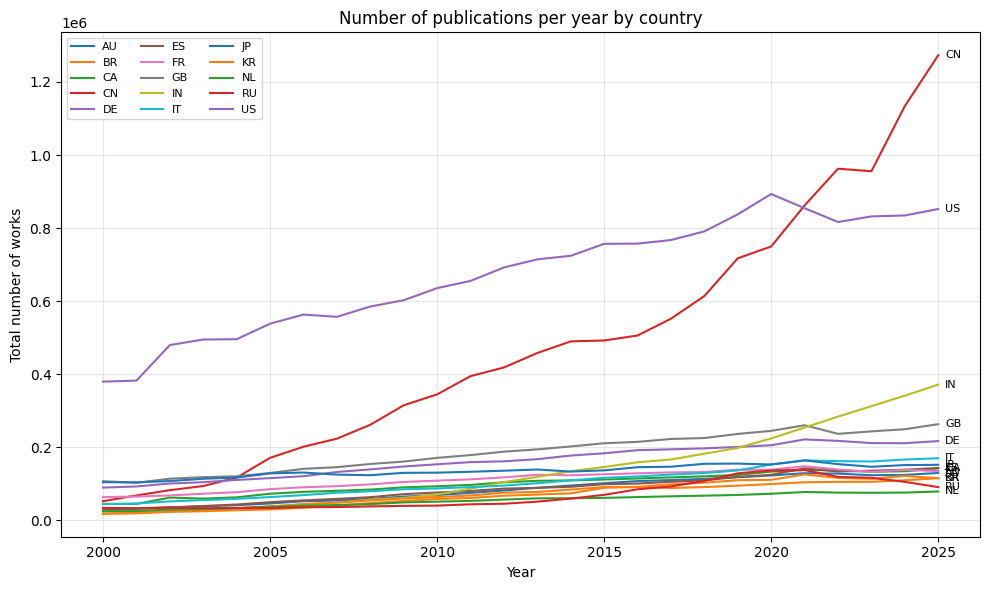

In [27]:
def plot_country_publications(country_dfs, title, ylabel, colName, labelPosition):
    plt.figure(figsize=(10,6))

    for country, df in sorted(country_dfs.items()):
        df_sorted = df.sort_values("year")
        plt.plot(df_sorted["year"], df_sorted[colName], label=country, linewidth=1.5)

        if labelPosition==1:
          # Add label at the end of the line (rightmost point)
          x = df_sorted["year"].iloc[-1]
          y = df_sorted[colName].iloc[-1]
          plt.text(x + 0.2, y, country, fontsize=8, va='center')
        elif labelPosition==-1:
          # Add label at the end of the line (leftmost point)
          x = df_sorted["year"].iloc[0]
          y = df_sorted[colName].iloc[0]
          plt.text(x - 0.8, y, country, fontsize=8, va='center')

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_country_publications(worksAll, "Number of publications per year by country",
                          "Total number of works", "median_abs", 1)

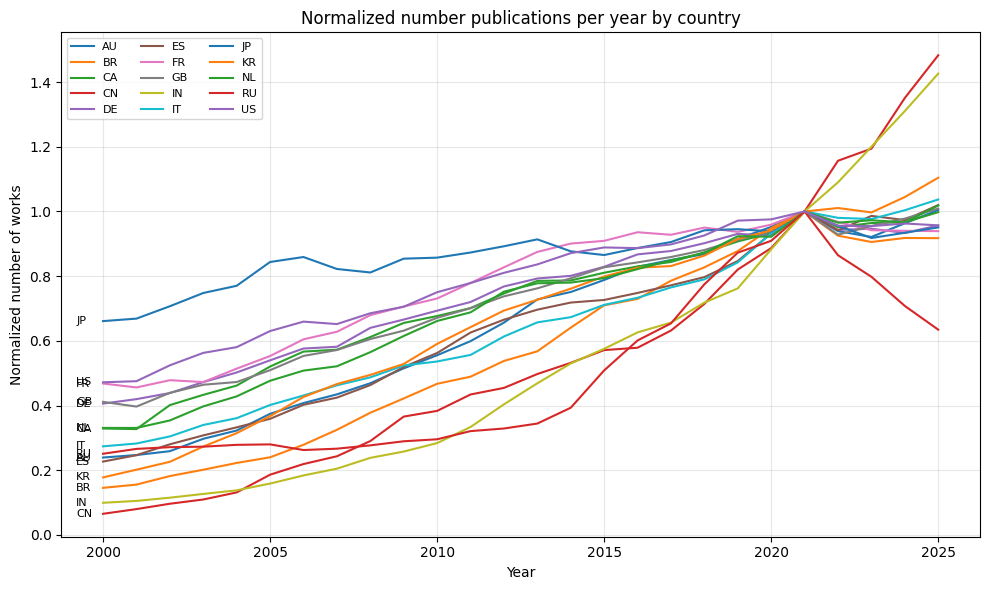

In [28]:
plot_country_publications(worksAll, "Normalized number publications per year by country",
                          "Normalized number of works", "median_norm", -1)

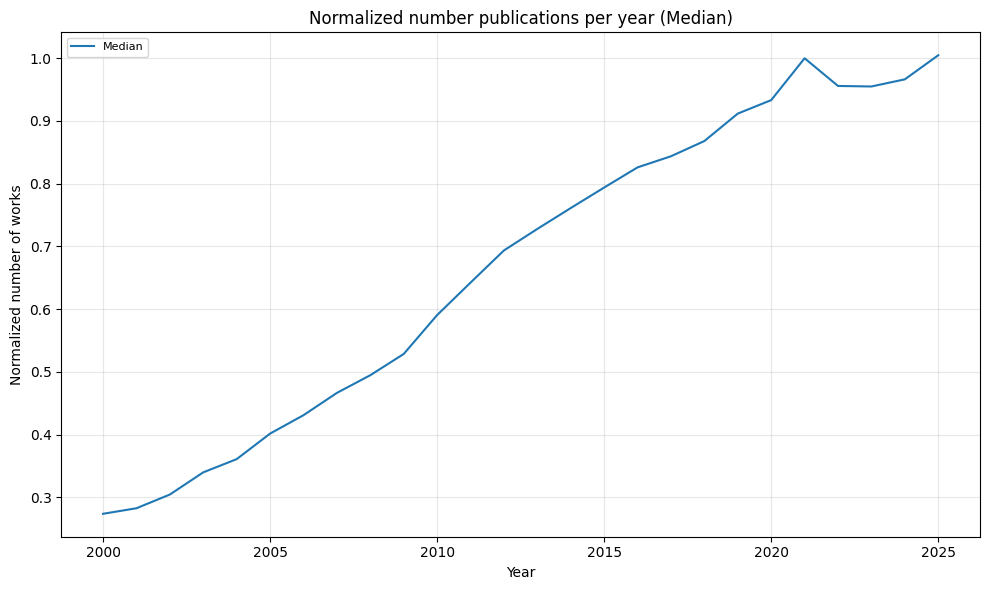

In [29]:
df_all = pd.concat(
    {country: df.set_index("year")["median_norm"] for country, df in worksAll.items()},
    axis=1
)

# Compute the median across countries for each year
median_per_year = df_all.median(axis=1, skipna=True)

# Optionally convert to a DataFrame for plotting or export
median_df = median_per_year.reset_index()
median_df.columns = ["year", "median_norm"]

worksMedian = {"Median": median_df}
plot_country_publications(worksMedian, "Normalized number publications per year (Median)",
                          "Normalized number of works", "median_norm", 0)

In [30]:
median_df

,year,median_norm
0,2000,0.273701
1,2001,0.282540
2,2002,0.304423
3,2003,0.339798
4,2004,0.360842
5,2005,0.401561
6,2006,0.430914
7,2007,0.466449
8,2008,0.494669
9,2009,0.528502


In [31]:
slopeUp=(median_df['median_norm'][21]-median_df['median_norm'][0])/21
slopeDown=(median_df['median_norm'][24]-median_df['median_norm'][21])/3
print(f"Slope up={slopeUp}; Slope down={slopeDown}")

Slope up=0.034585682122120084; Slope down=-0.01120177077592425


In [33]:
ratios = (pd.Series({c: (df.set_index("year").loc[2025, "median_norm"] / df.set_index("year").loc[2021, "median_norm"]-1)*100
                     for c, df in worksAll.items()})
          .sort_values(ascending=False))

print("Change from 2021 to 2025 (in %):")
print(ratios.round(1))
print(f"Mean = {ratios.mean():.1f}")

Change from 2021 to 2025 (in %):
CN    48.3
IN    42.6
KR    10.4
IT     3.7
ES     2.0
NL     1.9
GB     0.9
AU     0.5
CA    -0.2
US    -4.3
DE    -4.3
JP    -4.9
FR    -6.1
BR    -8.3
RU   -36.5
dtype: float64
Mean = 3.0


In [34]:
def years_lost_to_2025(df):
    s = df.set_index("year")["median_abs"].dropna()
    c2024 = s.loc[2025]
    prior = s.loc[s.index <= 2021]
    if prior.empty:
        return np.nan, np.nan
    y_closest = (prior - c2024).abs().idxmin()
    lost = 2024 - y_closest
    return int(lost), int(y_closest)

decliners = ratios[ratios < 0].index
lost_info = {
    c: years_lost_to_2025(worksAll[c]) for c in decliners
}

lost_df = (pd.DataFrame(lost_info, index=["years_lost","closest_year"])
             .T.sort_values("years_lost", ascending=False))

print(lost_df)
print(f"Mean = {lost_df['years_lost'].mean():.1f}")

    years_lost  closest_year
RU           7          2017
FR           6          2018
JP           4          2020
BR           4          2020
DE           3          2021
CA           3          2021
US           3          2021
Mean = 4.3


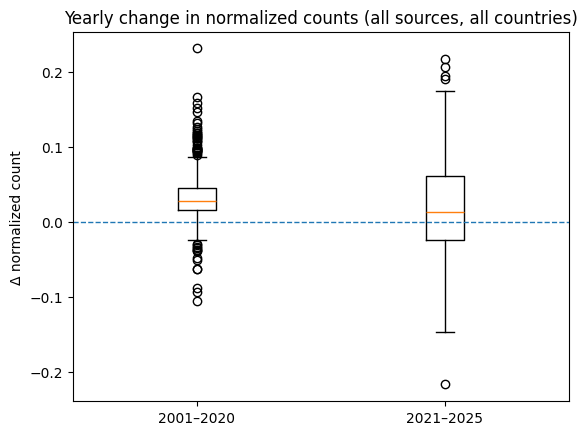

In [36]:
norm_cols = ["OA_norm", "SC_norm", "WoS_norm"]

pre_diffs_all  = []   # 2001–2020 (diffs for years <= 2020)
post_diffs_all = []   # 2021–2025

for cc, df in worksAll.items():
    df = df.sort_values("year")
    df_year_indexed = df.set_index("year")

    for col in norm_cols:
        if col not in df_year_indexed.columns:
            continue

        s = df_year_indexed[col]
        d = s.diff()  # d[year] = s[year] - s[year-1]

        # Pre-2021 diffs: current year 2001–2020
        pre_mask = (d.index >= 2001) & (d.index <= 2020)
        pre_diffs_all.extend(d[pre_mask].dropna().tolist())

        # 2021–2024 diffs: current year 2021–2025
        post_mask = (d.index >= 2021) & (d.index <= 2025)
        post_diffs_all.extend(d[post_mask].dropna().tolist())

# Single boxplot mixing all sources and all countries
plt.boxplot(
    [pre_diffs_all, post_diffs_all],
    tick_labels=["2001–2020", "2021–2025"]
)
plt.title("Yearly change in normalized counts (all sources, all countries)")
plt.ylabel("Δ normalized count")
plt.axhline(0, linestyle="--", linewidth=1)
plt.show()

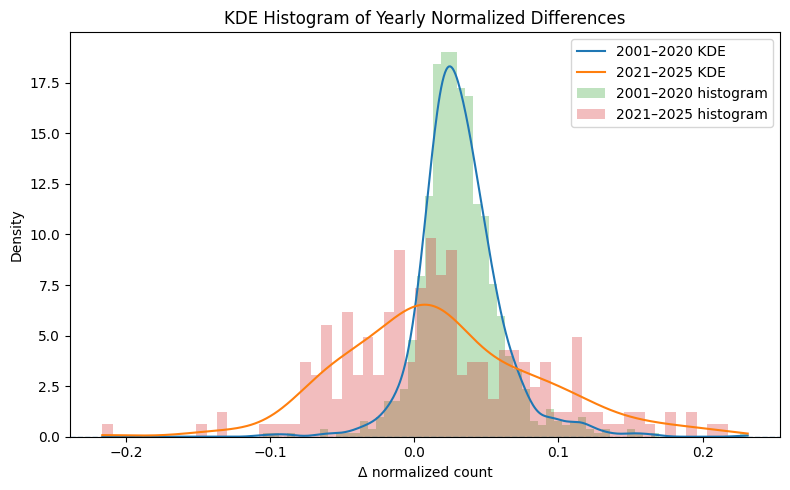

In [37]:
from scipy.stats import gaussian_kde

# Convert lists to numpy arrays
pre = np.array(pre_diffs_all)
post = np.array(post_diffs_all)

# KDE estimators
kde_pre = gaussian_kde(pre)
kde_post = gaussian_kde(post)

# Evaluate KDEs on a common grid
xmin = min(pre.min(), post.min())
xmax = max(pre.max(), post.max())
xgrid = np.linspace(xmin, xmax, 500)

# Plot
plt.figure(figsize=(8, 5))

# KDE curves
plt.plot(xgrid, kde_pre(xgrid), label="2001–2020 KDE")
plt.plot(xgrid, kde_post(xgrid), label="2021–2025 KDE")

# Histograms (density=True makes them comparable to KDE)
plt.hist(pre, bins=60, density=True, alpha=0.3, label="2001–2020 histogram")
plt.hist(post, bins=60, density=True, alpha=0.3, label="2021–2025 histogram")

plt.title("KDE Histogram of Yearly Normalized Differences")
plt.xlabel("Δ normalized count")
plt.ylabel("Density")
plt.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(pre_diffs_all, post_diffs_all, alternative="two-sided")

print("Mann–Whitney U statistic:", stat)
print("p-value:", p)

Mann–Whitney U statistic: 124542.0
p-value: 9.128926908275324e-08
